# 💰 Personal Finance Data Analysis & ETL Pipeline

**Goal:** To build a complete data pipeline from scratch.
In this project, I am generating a full year of simulated financial transactions, loading them into an SQLite database (the ETL process), and using Python to uncover hidden spending behaviors.


## Step 1: Creating and Storing the Data (ETL)
First, we need raw data. I wrote a Python script to generate 365 days of fake bank transactions. To make it realistic, I engineered a specific hidden behavior: the "user" tends to spend much more money on entertainment and dining out during the weekends.

Then, I load this data directly into an SQLite database so we can query it using SQL.

In [1]:
import pandas as pd
import numpy as np
import random
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate Data
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', end='2023-12-31')
data = []

for date in dates:
    if date.day == 1: data.append([date, 'Income', 'Salary', 5000.00, 'Credit'])
    if date.day == 2: data.append([date, 'Housing', 'Rent', 1500.00, 'Debit'])

    for _ in range(np.random.randint(1, 5)):
        category = random.choice(['Groceries', 'Entertainment', 'Transport', 'Dining Out', 'Utilities'])
        amount = np.random.uniform(10, 50) * (2.5 if date.weekday() >= 5 and category in ['Entertainment', 'Dining Out'] else 1)
        data.append([date, category, 'Card Payment', round(amount, 2), 'Debit'])

df = pd.DataFrame(data, columns=['Date', 'Category', 'Description', 'Amount', 'Transaction_Type'])

# 2. Load into SQLite Database
conn = sqlite3.connect('finance_database.db')
df.to_sql('transactions', conn, if_exists='replace', index=False)
print("Data generated and database built successfully! 🗄️")

Data generated and database built successfully! 🗄️


## Step 2: Behavioral Analysis (Weekend vs. Weekday)
Now, let's act like data detectives. Do we actually spend more on fun things during the weekend?

I am using a SQL query to pull the data for 'Dining Out' and 'Entertainment'. Then, I use Pandas to figure out which days were weekends, and Seaborn to draw a bar chart comparing the averages.

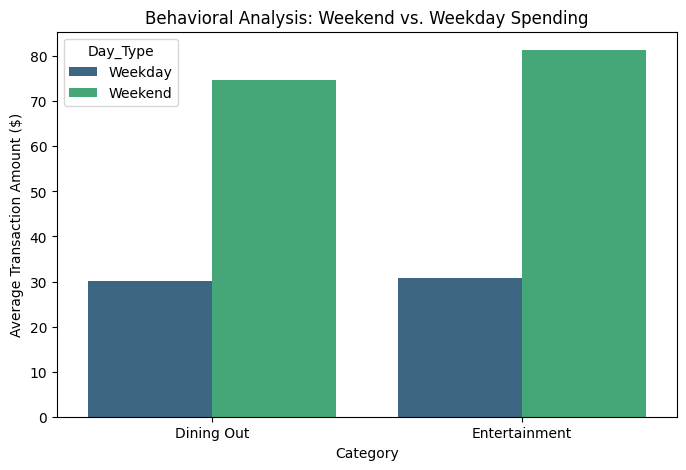

In [2]:
# Query the data
query = "SELECT Date, Category, Amount FROM transactions WHERE Category IN ('Entertainment', 'Dining Out');"
df_fun = pd.read_sql_query(query, conn)

# Format dates and find weekends
df_fun['Date'] = pd.to_datetime(df_fun['Date'], format='mixed', dayfirst=True)
df_fun['Day_Type'] = df_fun['Date'].dt.dayofweek.apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
df_behavior = df_fun.groupby(['Category', 'Day_Type'])['Amount'].mean().reset_index()

# Draw Chart
plt.figure(figsize=(8, 5))
sns.barplot(data=df_behavior, x='Category', y='Amount', hue='Day_Type', palette='viridis')
plt.title('Behavioral Analysis: Weekend vs. Weekday Spending')
plt.ylabel('Average Transaction Amount ($)')
plt.show()

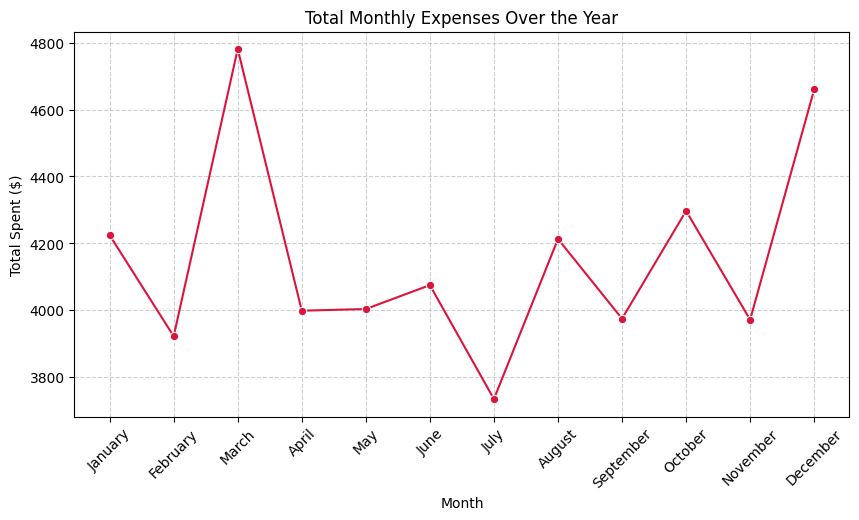

In [3]:
# Query all debit transactions
query_monthly = "SELECT Date, Amount FROM transactions WHERE Transaction_Type = 'Debit';"
df_monthly = pd.read_sql_query(query_monthly, conn)

# Group by month
df_monthly['Date'] = pd.to_datetime(df_monthly['Date'], format='mixed', dayfirst=True)
df_monthly['Month'] = df_monthly['Date'].dt.month_name()

# Order the months correctly
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
monthly_spending = df_monthly.groupby('Month')['Amount'].sum().reindex(months).reset_index()

# Draw Chart
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_spending, x='Month', y='Amount', marker='o', color='crimson')
plt.title('Total Monthly Expenses Over the Year')
plt.xticks(rotation=45)
plt.ylabel('Total Spent ($)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

## Step 3: Monthly Spending Trends
Next, let's look at the big picture over time. Are there certain months where spending spikes?

I am querying all the 'Debit' (money out) transactions from the database and grouping them by month to build a line chart showing our cash flow over the year.

## Step 4: Annual Spending Breakdown
Finally, where is the bulk of the money actually going?

To answer this, I am summing up all the expenses grouped by category and using a pie chart to show the total breakdown of the yearly budget.

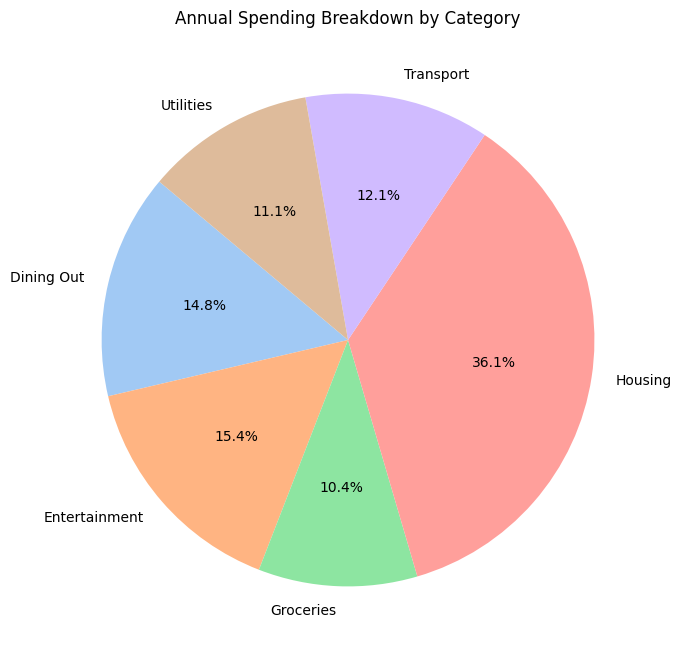

In [4]:
# Query spending by category
query_pie = "SELECT Category, SUM(Amount) as Total FROM transactions WHERE Transaction_Type = 'Debit' GROUP BY Category;"
df_pie = pd.read_sql_query(query_pie, conn)

# Draw Chart
plt.figure(figsize=(8, 8))
plt.pie(df_pie['Total'], labels=df_pie['Category'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Annual Spending Breakdown by Category')
plt.show()

## 🚀 Final Takeaways
1. **ETL is powerful:** We successfully extracted raw generated data, transformed the dates, and loaded it into a database.
2. **Behavioral tracking works:** The bar chart clearly proved our hypothesis that weekend spending is significantly higher for social categories.
3. **Data tells a story:** By combining SQL for querying and Pandas/Seaborn for visualization, we turned a messy list of thousands of transactions into clean, actionable business (or personal!) insights.